# <span style="color:green"> Lecture 07 notebook </span>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## <span style="color:blue">  Exercise 07.2 </span>

Finora, nelle simulazioni, è stato impostato un cutoff sferico. Sono state ora implementate le correzioni di coda, per ricostruire il potenziale long-range. Nelle regioni in cui $r > r_c$ assumiamo che $g(r) = 1$, cioè che il sistema si comporti come un gas perfetto. Le correzioni sono applicate a energia interna $U$ e pressione $P$.
$$ \frac{\langle V_{LJ} \rangle_{\text{tail}}}{N} = \frac{8\pi\rho_{LJ}\varepsilon}{9r_{c(LJ)}^9} - \frac{8\pi\rho_{LJ}\varepsilon}{3r_{c(LJ)}^3} $$,

$$ \frac{\langle W_{LJ} \rangle_{\text{tail}}}{3N\varepsilon} = 32\pi\rho_{LJ} \left[ \frac{1}{9r_{c(LJ)}^9} - \frac{1}{6r_{c(LJ)}^3} \right] $$

Sono rappresentati i periodi di equilibrazione di $50000$ step ciascuno per dinamica molecolare e Monte Carlo.

Energia media degli ultimi 20000 step, a equilibrio raggiunto: -4.77


[]

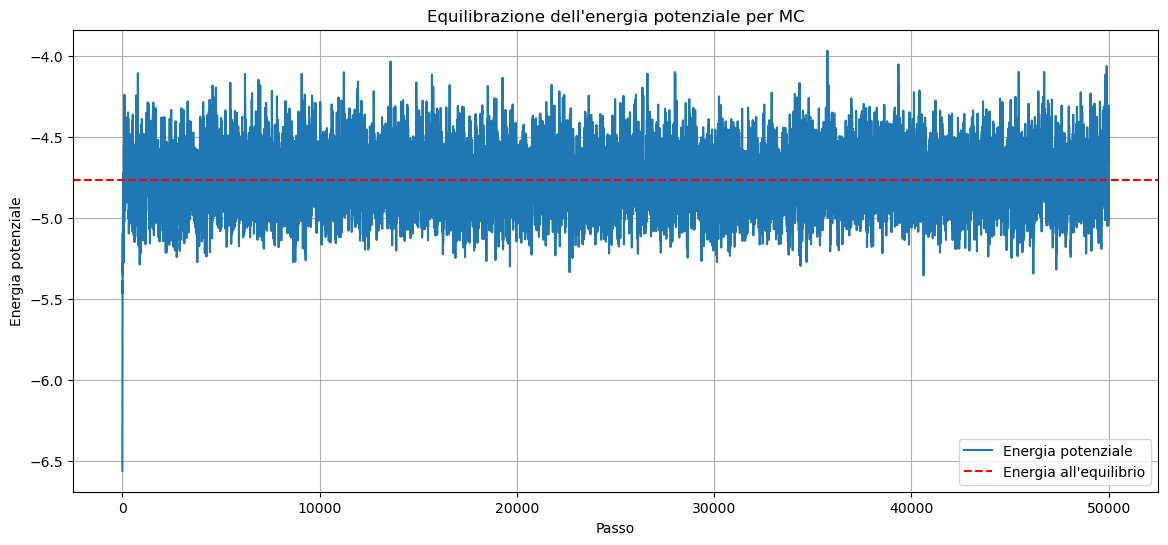

In [36]:
block, energy = np.loadtxt("Exercise_07.2/potential_energyMC_2.dat", usecols = (0, 1), unpack = True)
print(f"Energia media degli ultimi 20000 step, a equilibrio raggiunto: { np.mean(energy[30000:-1]):.2f}")


plt.figure(figsize=(14,6))
plt.plot(block, energy, label = "Energia potenziale")
plt.grid(True)
plt.title("Equilibrazione dell'energia potenziale per MC")
plt.axhline(np.mean(energy[1000:-1]), color = 'red', linestyle = "--", label = "Energia all'equilibrio")
plt.xlabel("Passo")
plt.ylabel("Energia potenziale")
plt.legend()
plt.plot()

Temperatura media degli ultimi 20000 step, a equilibrio raggiunto: 1.11


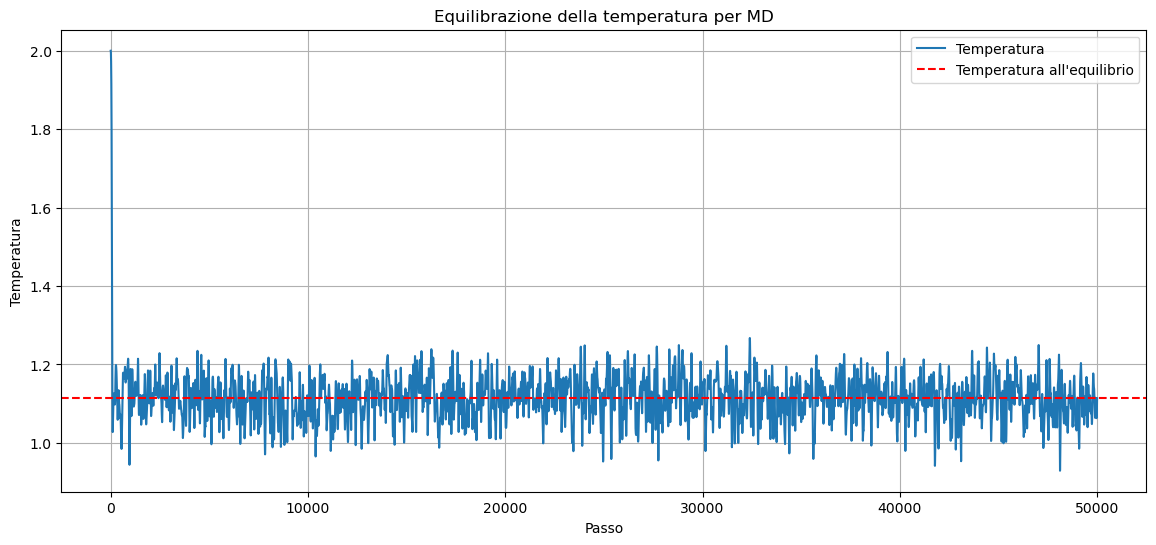

In [31]:
plt.figure(figsize=(14,6))

block, temperature = np.loadtxt("Exercise_07.2/temperatureMD_2.dat", usecols = (0, 1), unpack = True)
print(f"Temperatura media degli ultimi 20000 step, a equilibrio raggiunto: { np.mean(temperature[30000:-1]):.2f}")

plt.plot(block, temperature, label = "Temperatura")
plt.axhline(np.mean(temperature[1000:-1]), color = 'red', linestyle = "--", label = "Temperatura all'equilibrio")
plt.grid(True)
plt.title("Equilibrazione della temperatura per MD")
plt.xlabel("Passo")
plt.ylabel("Temperatura")
plt.legend()
plt.plot();

Energia media degli ultimi 20000 step, a equilibrio raggiunto: -5.45


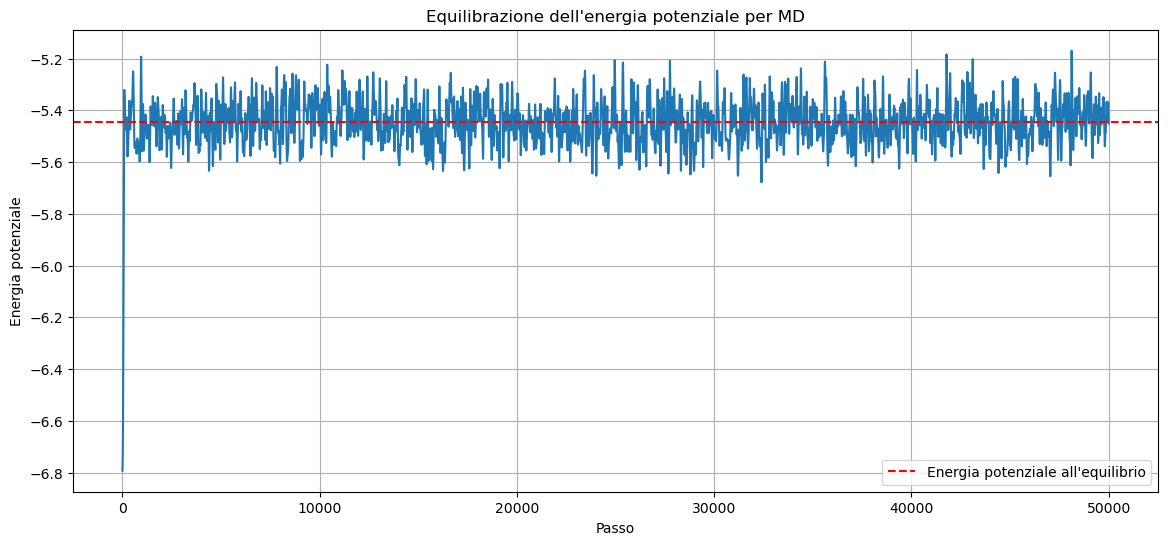

In [32]:
plt.figure(figsize=(14,6))

block, energy = np.loadtxt("Exercise_07.2/potential_energyMD_2.dat", usecols = (0, 1), unpack = True)
print(f"Energia media degli ultimi 20000 step, a equilibrio raggiunto: { np.mean(energy[30000:-1]):.2f}")



plt.plot(block, energy)
plt.grid(True)
plt.title("Equilibrazione dell'energia potenziale per MD")
plt.axhline(np.mean(energy[1000:-1]), color = 'red', linestyle = "--", label = "Energia potenziale all'equilibrio")
plt.xlabel("Passo")
plt.ylabel("Energia potenziale")
plt.legend()
plt.plot();

Osserviamo come i valori originati da MC fluttuino in modo molto più rilevante e fitto rispetto a quelli generati da MD. Questo è importante per l'autocorrelazione...

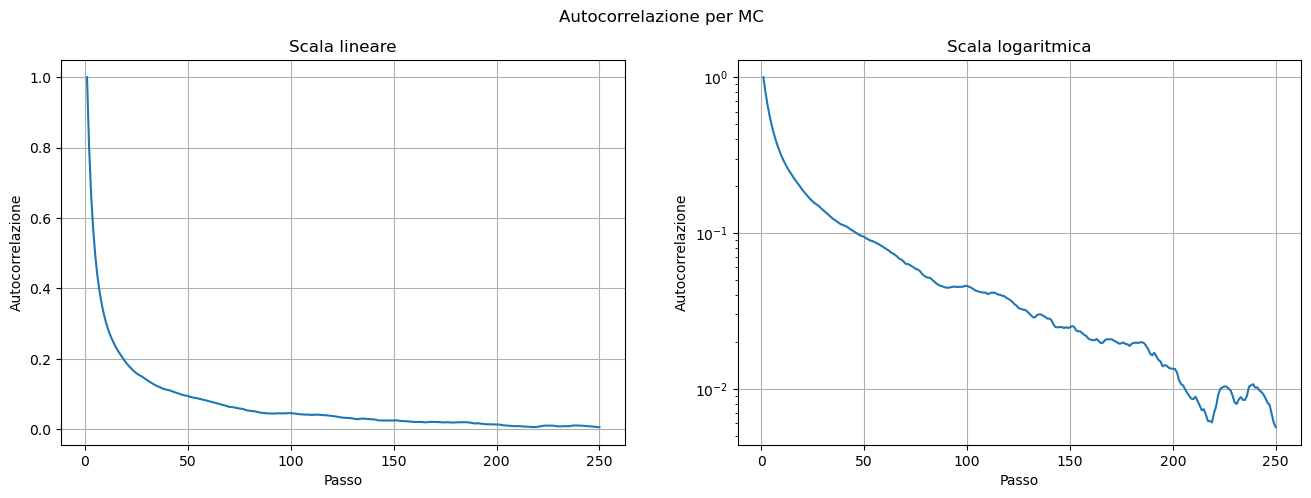

In [35]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

block, energy = np.loadtxt("Exercise_07.2/potential_energyMC07.2.dat", usecols = (0, 1), unpack = True)

tmax = len(block)
chi_MC = []

max_lag = 250;

denominator = 1/tmax * np.sum(energy[:(tmax)]*energy[:(tmax)]) - (1/tmax*np.sum(energy[:(tmax)]))**2

for i in range (max_lag):
    upper_limit = tmax - i
    norm = 1/upper_limit

    first_term = norm*np.sum(energy[:upper_limit]*energy[i:(tmax)])
    second_term = norm*np.sum(energy[:upper_limit])*norm*np.sum(energy[i:(tmax)])

    chi_MC.append((first_term - second_term)/denominator)


t_steps = np.arange(len(chi_MC))
y_data = np.array(chi_MC)

axes[0].plot(block[:max_lag], chi_MC)
axes[0].grid(True)
axes[0].set_title("Scala lineare")
axes[0].set_xlabel("Passo")

axes[0].set_ylabel("Autocorrelazione")


axes[1].plot(block[:max_lag], chi_MC)
axes[1].grid(True)
axes[1].set_yscale('log')
axes[1].set_title("Scala logaritmica")
axes[1].set_xlabel("Passo")

axes[1].set_ylabel("Autocorrelazione")

plt.suptitle("Autocorrelazione per MC")
plt.show()

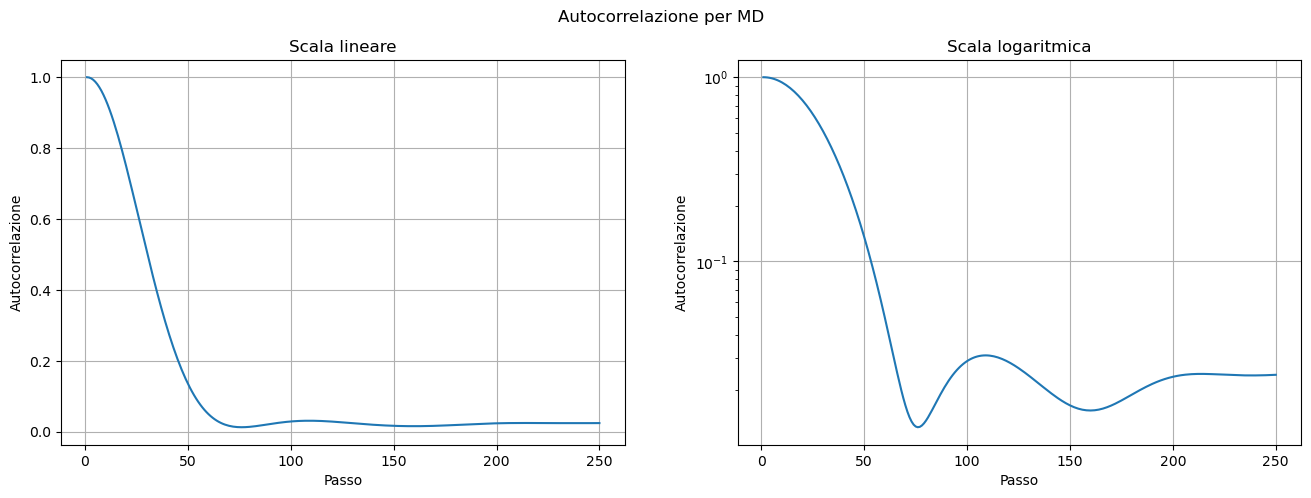

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

block, energy = np.loadtxt("Exercise_07.2/potential_energyMD07.2.dat", usecols = (0, 1), unpack = True)

tmax = len(block)
chi = []

max_lag = 250;

denominator = 1/tmax * np.sum(energy[:(tmax)]*energy[:(tmax)]) - (1/tmax*np.sum(energy[:(tmax)]))**2

for i in range (max_lag):
    upper_limit = tmax - i
    norm = 1/upper_limit

    first_term = norm*np.sum(energy[:upper_limit]*energy[i:(tmax)])
    second_term = norm*np.sum(energy[:upper_limit])*norm*np.sum(energy[i:(tmax)])

    chi.append((first_term - second_term)/denominator)

t_steps = np.arange(len(chi))
y_data = np.array(chi)



axes[0].plot(block[:max_lag], chi)
axes[0].grid(True)

axes[0].set_title("Scala lineare")
axes[0].set_xlabel("Passo")
axes[0].set_ylabel("Autocorrelazione")


axes[1].plot(block[:max_lag], chi)
axes[1].grid(True)

axes[1].set_yscale('log')
axes[1].set_title("Scala logaritmica")
axes[1].set_xlabel("Passo")
axes[1].set_ylabel("Autocorrelazione")

plt.suptitle("Autocorrelazione per MD")
plt.show()

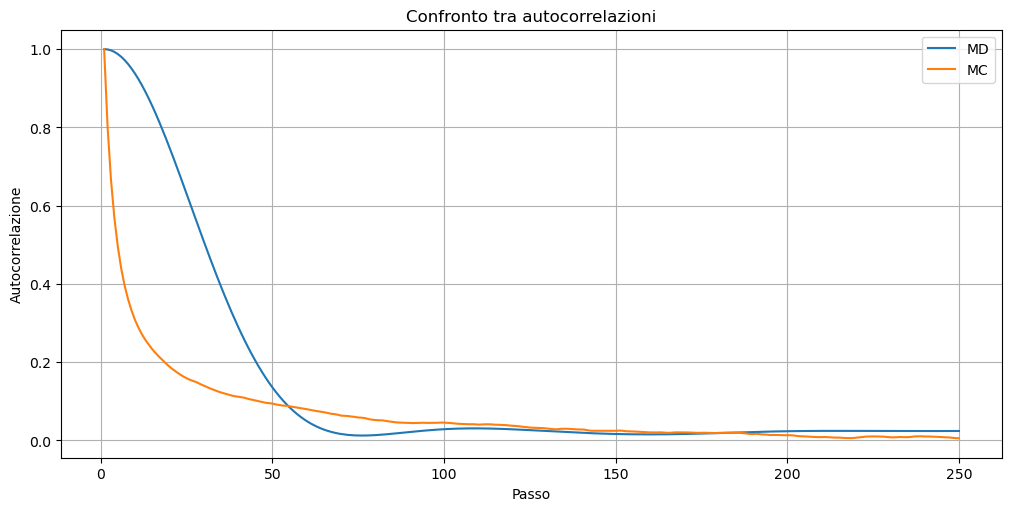

In [25]:

fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
ax.plot(block[:max_lag], chi, label='MD') 
ax.plot(block[:max_lag], chi_MC, label='MC') 
ax.set_xlabel('Passo')  
ax.set_ylabel('Autocorrelazione') 
ax.grid(True)
ax.set_title("Confronto tra autocorrelazioni")  
ax.legend();

Il tempo di autocorrelazione è più lungo per MD, e non decade esponenzialmente nei primissimi passi. Questo è dovuto al fatto che nel MC le particelle hanno un moto puramente casuale, e le posizioni consecutive assunte dalle particelle sono legate solamente dal garantire che le proprietà macroscopiche rimangano simili. 

In MD, invece, le particelle seguono le equazioni del Verlet, e hanno perciò traiettorie "continue". Questo porta l'autocorrelazione della MD a decadere molto più lentamente rispetto a quella del MC.

Possiamo anche osservare un aumento dell'autocorrelazione intorno al 100esimo passo per la MD. Forse, questo potrebbe essere dovuto a correlazioni a scala temporale più lunga nel fluido

In [3]:
block, energy = np.loadtxt("Exercise_07.2/potential_energyMC07.2.dat", usecols = (0, 1), unpack = True)

M = len(block)
L = np.arange(10, 5001, 10)
errors = []

for l in L:
    N = int(M/l)
    mean = []
    for i in range(N):
        mean.append(np.mean(energy[i*l:(i+1)*l]))
        
    variance = np.var(mean)
    errors.append(np.sqrt(variance/(N-1)))

block, energyMD = np.loadtxt("Exercise_07.2/potential_energyMD07.2.dat", usecols = (0, 1), unpack = True)

M = len(block)
L = np.arange(10, 5001, 10)
errorsMD = []

for l in L:
    N = int(M/l)
    meanMD = []
    for i in range(N):
        meanMD.append(np.mean(energyMD[i*l:(i+1)*l]))
        
    varianceMD = np.var(meanMD)
    errorsMD.append(np.sqrt(varianceMD/(N-1)))


[]

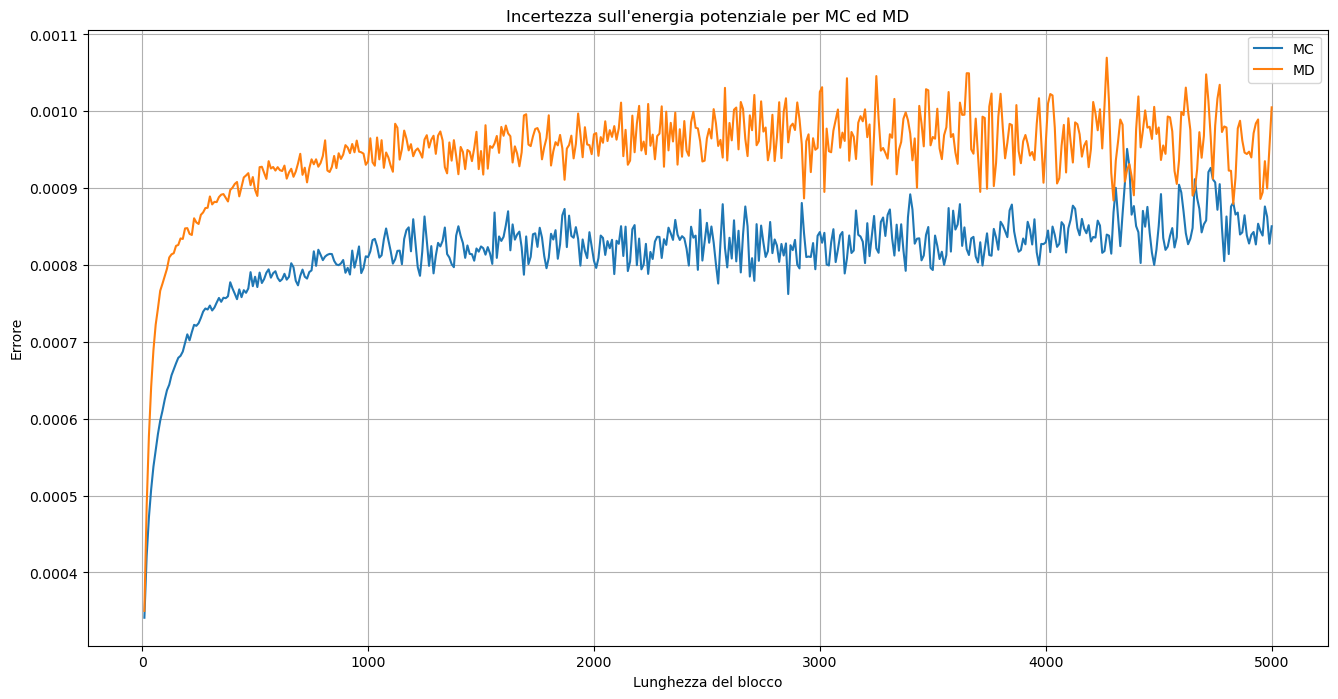

In [4]:
plt.figure(figsize=(16, 8))


plt.plot(L, errors, label = "MC")
plt.plot(L, errorsMD, label="MD")
plt.grid(True)
plt.title("Incertezza sull'energia potenziale per MC ed MD")
plt.xlabel("Lunghezza del blocco")
plt.ylabel("Errore")
plt.legend()
plt.plot()

Possiamo osservare come per blocchi molto piccoli, a causa della forte autocorrelazione dei dati, l'incertezza sia decisamente sottostimata dal data blocking. L'incertezza stabilizza per una lunghezza dei blocchi di circa 2000 step, quando la parte di dati tra loro autocorrelati diventa trascurabile.

Il fatto che la MD stabilizzi ad un valore maggiore rispetto al MC è probabilmente dovuto al maggior tempo di correlazione, che influenza l'errore all'interno dei blocchi e sovrasta l'effetto di simulazione dell'ensemble microcanonico. 

All'aumentare della lunghezza dei blocchi l'incertezza diviene stabile, dal momento che il teorema del limite centrale è ormai rispettato in ogni blocco. La distribuzione che stiamo campionando è ormai centrata sul valore vero e continua a farsi più stretta, ma il numero di blocchi diminuisce e l'errore rimane così costante, avendo raggiunto l'errore statistico.

I valori successivi sono calcolati con $50$ blocchi di $3000$ passi ciascuno.

[]

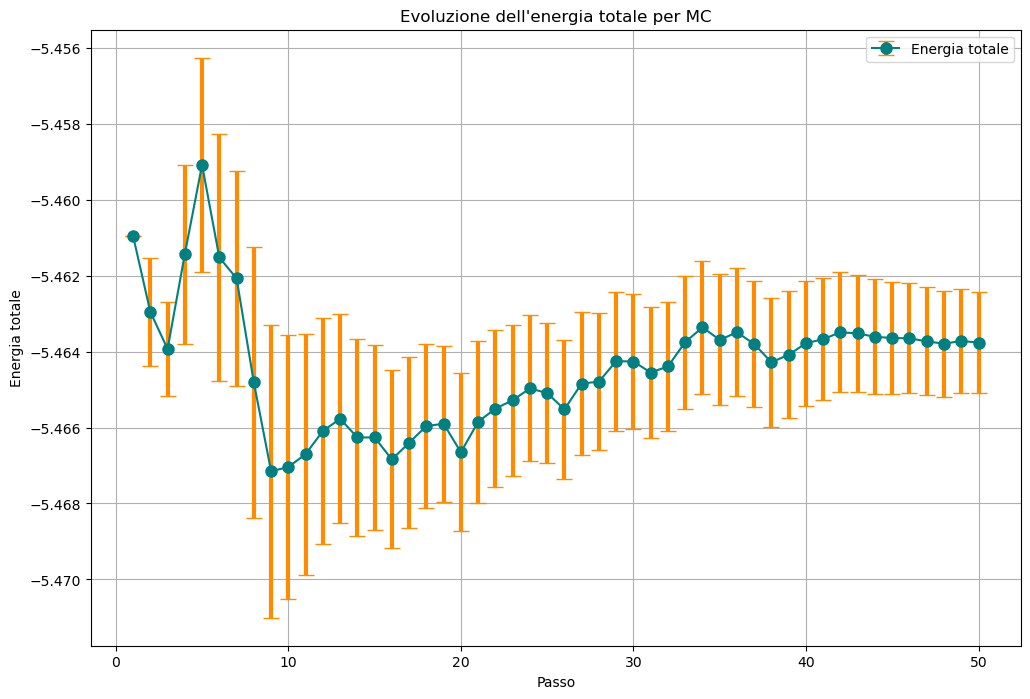

In [11]:
N = 100
L = 2000

plt.figure(figsize=(12, 8))

block, energy, error = np.loadtxt("Exercise_07.4/total_energyMC07.4.dat", usecols = (0, 2, 3), unpack = True)


plt.errorbar(block, energy, yerr = error, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=3, capsize=6, markersize=8, label='Energia totale')
plt.grid(True)
plt.title("Evoluzione dell'energia totale per MC")
plt.xlabel("Passo")
plt.ylabel("Energia totale")
plt.legend()
plt.plot()

[]

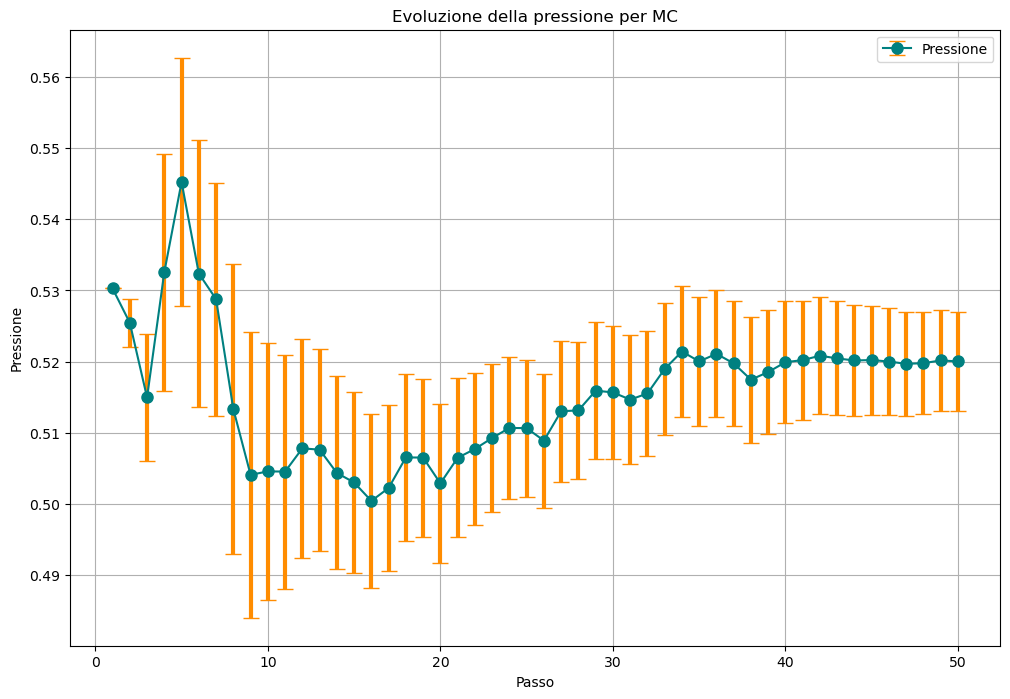

In [12]:
block, energy, error = np.loadtxt("Exercise_07.4/pressureMC07.4.dat", usecols = (0, 2, 3), unpack = True)

plt.figure(figsize=(12, 8))
plt.errorbar(block, energy, yerr = error, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=3, capsize=6, markersize=8, label='Pressione')
plt.grid(True)
plt.title("Evoluzione della pressione per MC")
plt.xlabel("Passo")
plt.ylabel("Pressione")
plt.legend()
plt.plot()

[]

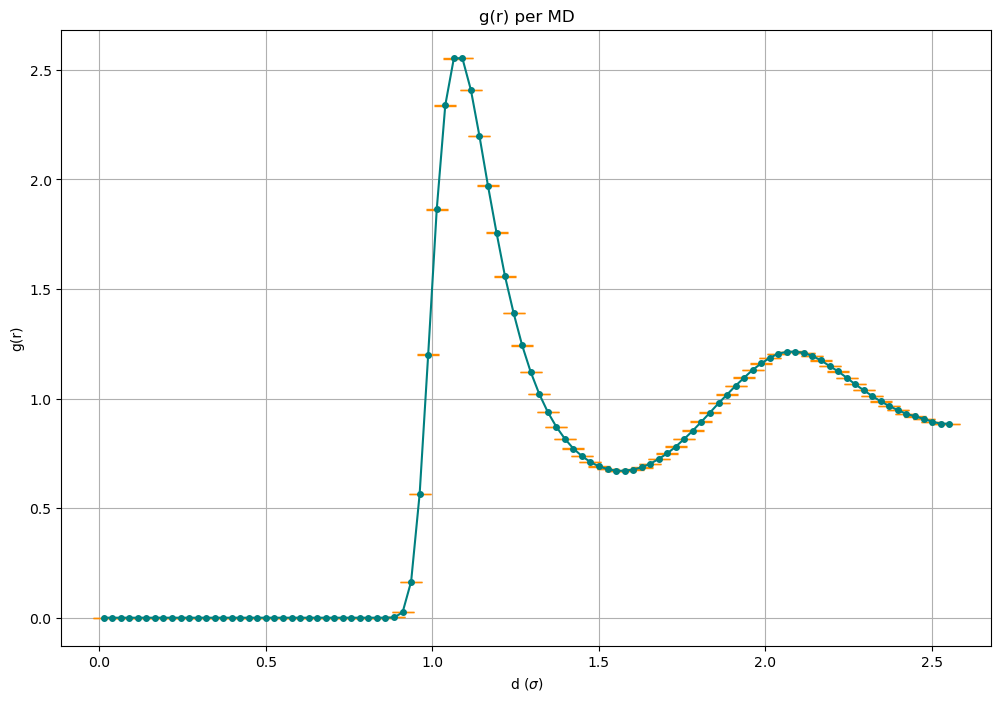

In [19]:
d, g, err = np.loadtxt("Exercise_07.4/final_gofrMC07.4.dat", usecols = (0,1,2), unpack = True)


plt.figure(figsize=(12, 8))
plt.errorbar(d, g, yerr = err, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=2, capsize=8, markersize=4, label='g(r)')
plt.grid(True)
plt.title("g(r) per MD")
plt.xlabel(r"d ($\sigma$)")
plt.ylabel("g(r)")
plt.plot()

[]

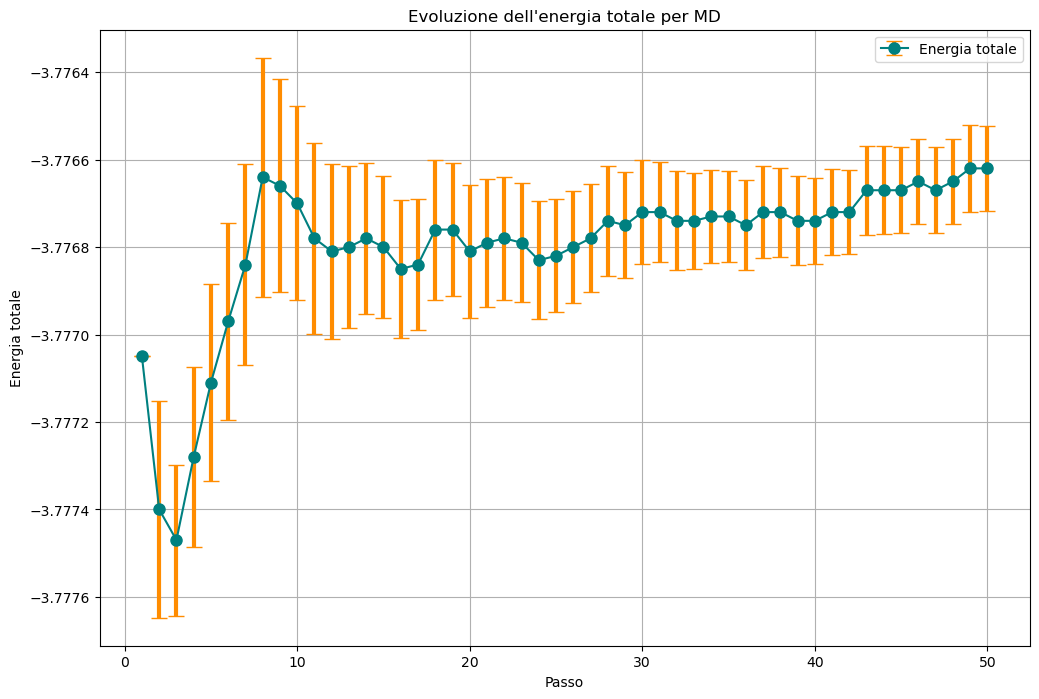

In [13]:
block, energy, error = np.loadtxt("Exercise_07.4/total_energyMD07.4.dat", usecols = (0, 2, 3), unpack = True)

plt.figure(figsize=(12, 8))
plt.errorbar(block, energy, yerr = error, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=3, capsize=6, markersize=8, label='Energia totale')
plt.grid(True)
plt.title("Evoluzione dell'energia totale per MD")
plt.xlabel("Passo")
plt.ylabel("Energia totale")
plt.legend()
plt.plot()

[]

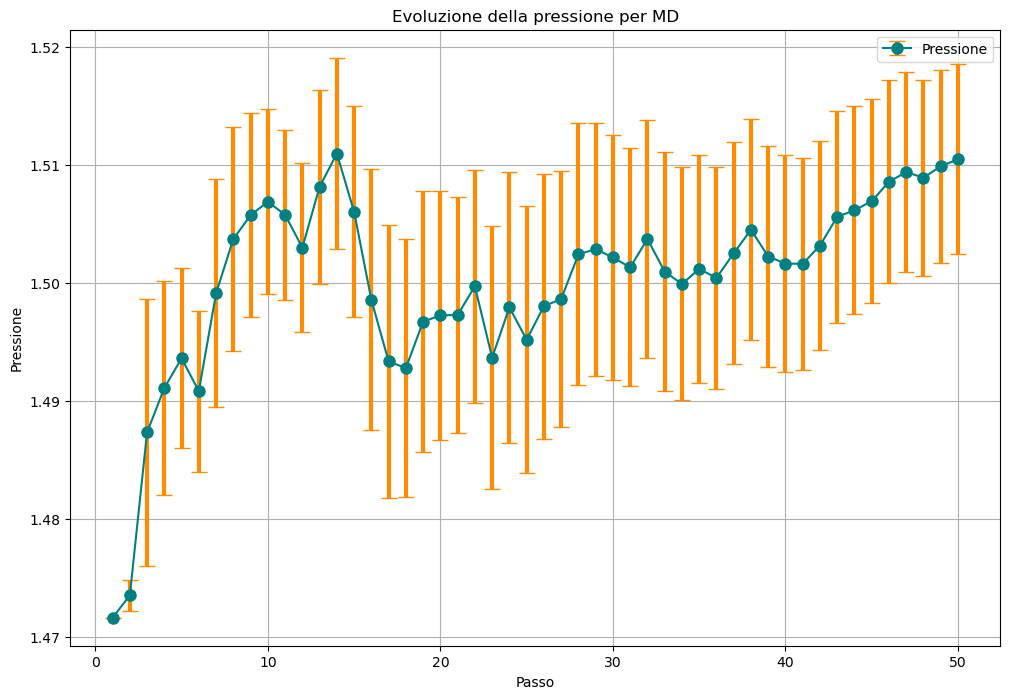

In [14]:
block, energy, error = np.loadtxt("Exercise_07.4/pressureMD07.4.dat", usecols = (0, 2, 3), unpack = True)
plt.figure(figsize=(12, 8))

plt.errorbar(block, energy, yerr = error, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=3, capsize=6, markersize=8, label='Pressione')
plt.grid(True)
plt.title("Evoluzione della pressione per MD")
plt.xlabel("Passo")
plt.ylabel("Pressione")
plt.legend()
plt.plot()

[]

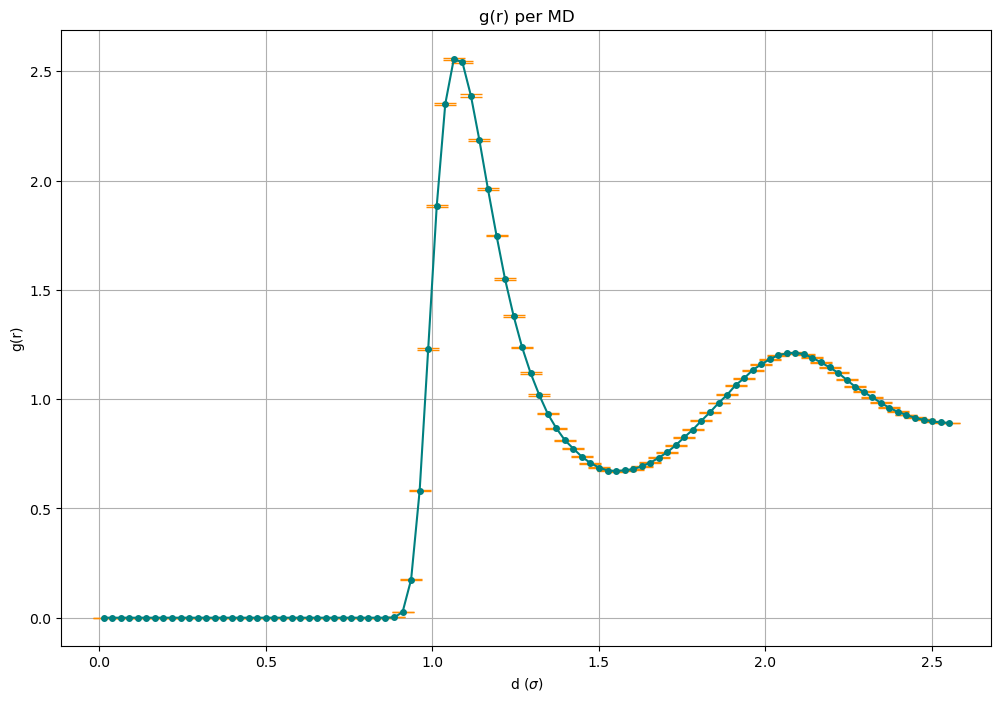

In [18]:
d, g, err = np.loadtxt("Exercise_07.4/final_gofrMD07.4.dat", usecols = (0,1,2), unpack = True)

plt.figure(figsize=(12, 8))
plt.errorbar(d, g, yerr = err, fmt='o-', color='teal', 
             ecolor='darkorange', elinewidth=2, capsize=8, markersize=4, label='g(r)')
plt.grid(True)
plt.title("g(r) per MD")
plt.xlabel(r"d ($\sigma$)")
plt.ylabel("g(r)")
plt.plot()

Possiamo osservare come le distribuzioni $g(r)$ presentino una probabilità sostanizalmente nulla fino a che il potenziale di Lennart-Jones rimane positivo, per andare invece incontro a una netta impennata di probabilità in prossimità del valore per cui questo cambia segno, vale a dire intorno a $1\sigma$. 

Il picco successivo lo si trova inprossimità di $2\sigma$, a causa della densità dei secondi vicini: queste sono infatti le particelle che, a loro volta, si trovano a $1\sigma$ di distanza dalle particella precedente. Ovviamente, i picchi sono più smorzati man mano che ci si allontana dall'origine per via dell'isotropia dello spazio. 

Allontanandoci ulteriormente, notiamo che la $g(r)$ si stabilizza intorno a un valore di $1$. Questo è ragionevole se teniamo a mente che syiamo calcolando la densità relativa a quella di un gas ideale, dove non ci sono forse interparticellari e dunque la distribuzione radiale è uniforme. All'allontanarci dalla particella, dunque, le posizioni delle particelle diventano sempre più equidistribuite e la distribuzione rassomiglia sempre di più a quella di un gas ideale.

Confronto delle quantità misurate

[]

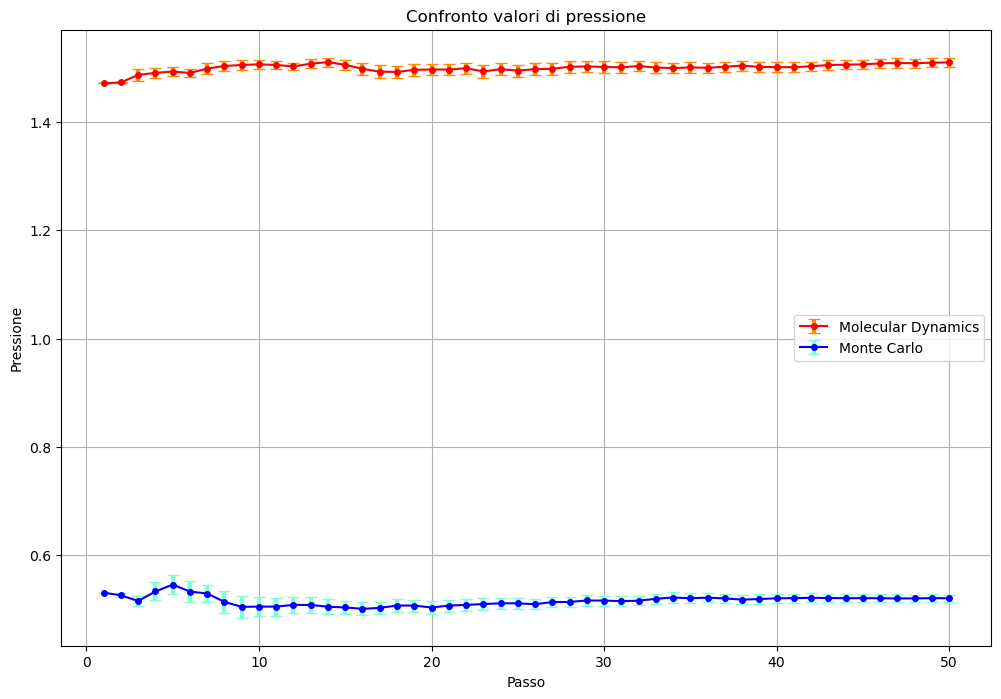

In [4]:
block, energy, error = np.loadtxt("Exercise_07.4/pressureMD07.4.dat", usecols = (0, 2, 3), unpack = True)
plt.figure(figsize=(12, 8))

plt.errorbar(block, energy, yerr = error, fmt='o-', color='red', 
             ecolor='darkorange', elinewidth=3, capsize=4, markersize=4, label='Molecular Dynamics')

block, energy, error = np.loadtxt("Exercise_07.4/pressureMC07.4.dat", usecols = (0, 2, 3), unpack = True)


plt.errorbar(block, energy, yerr = error, fmt='o-', color='blue', 
             ecolor='aquamarine', elinewidth=3, capsize=4, markersize=4, label='Monte Carlo')
plt.grid(True)
plt.title("Confronto valori di pressione")
plt.xlabel("Passo")
plt.ylabel("Pressione")
plt.legend()
plt.plot()

Il fatto che la pressione risulti molto più alta per la Dinamica Molecolare è ragionevole, se pensiamo che la pressione è computata come 
$$\frac{2}{3}\rho E_k + \frac{(p_{tail}\cdot n_{part} + 48 \cdot viriale/3)}{V},$$ con $E_k$ energia cinetica e $\rho$ densità del sistema. L'energia cinetica, infatti, non è computata nella simulazione Monte Carlo, la cui pressione risulterà dunque minore di un fattore $(2/3) \rho E_k$. Nel grafico sottostante è riportato il confronto tra la pressione del MC e la pressione nella MD cui è stato sottratto ill termine relativo all'$E_k$..

[]

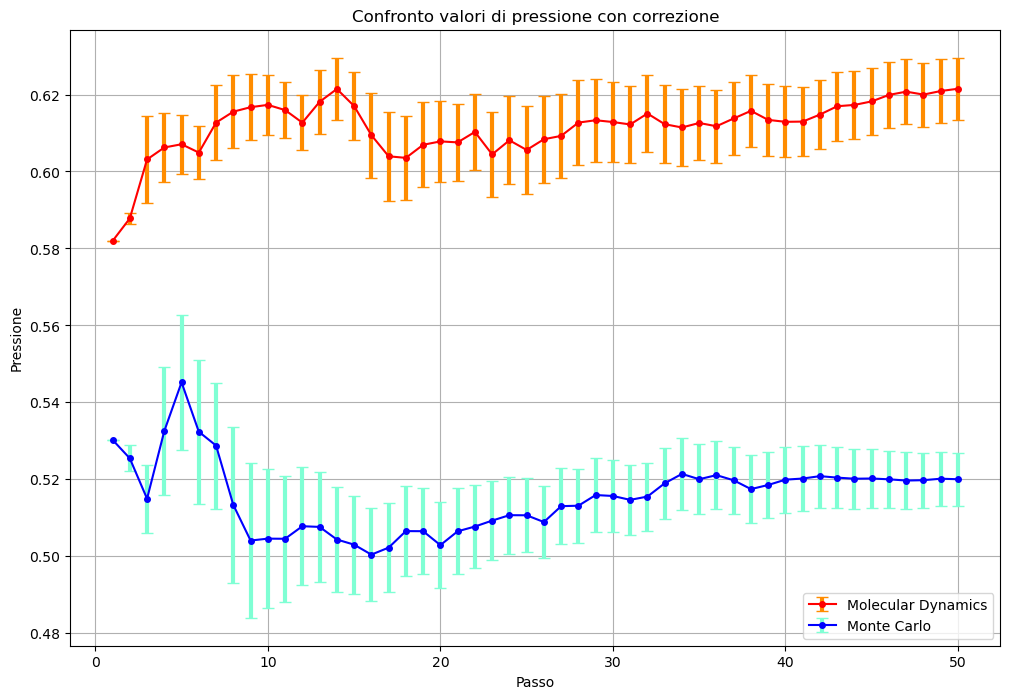

In [21]:
rho = 0.8

block, energy, error = np.loadtxt("Exercise_07.4/pressureMD07.4.dat", usecols = (0, 2, 3), unpack = True)
kenergy = np.loadtxt("Exercise_07.4/kinetic_energyMD07.4.dat", usecols = (2), unpack = True)
plt.figure(figsize=(12, 8))

term = 2/3*rho*kenergy
plt.errorbar(block, energy-term, yerr = error, fmt='o-', color='red', 
             ecolor='darkorange', elinewidth=3, capsize=4, markersize=4, label='Molecular Dynamics')

block, energy, error = np.loadtxt("Exercise_07.4/pressureMC07.4.dat", usecols = (0, 2, 3), unpack = True)


plt.errorbar(block, energy, yerr = error, fmt='o-', color='blue', 
             ecolor='aquamarine', elinewidth=3, capsize=4, markersize=4, label='Monte Carlo')
plt.grid(True)
plt.title("Confronto valori di pressione con correzione")
plt.xlabel("Passo")
plt.ylabel("Pressione")
plt.legend()
plt.plot()

I due valori risultano ora molto più vicini. Il grafico probabilmente non è molto significativo dal punto di vista quantitativo né troppo corretto, non bisognerebbe sommare alla media progressiva della pressione la media progressiva dell'energia cinetica, ma fa capire come questa assenza sia la maggior causa della discrepanza rilevata in precedenza. 

La rimanente inconciliabilità tra i valori potrebbe essere dovuta a diversità intrinseca dei due algoritmi, o alla leggere differenza di temperatura $T$, esatta per MC ma raggiunta empiricamente e soggetta a seppur leggere fluttuazioni in MD.

[]

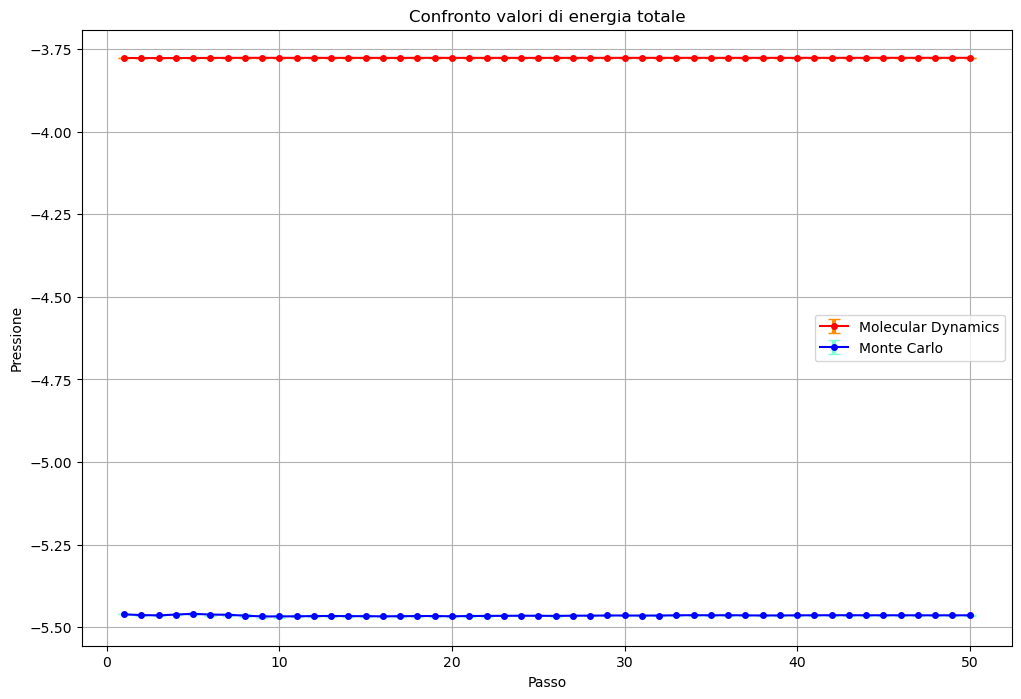

In [22]:
block, energy, error = np.loadtxt("Exercise_07.4/total_energyMD07.4.dat", usecols = (0, 2, 3), unpack = True)
plt.figure(figsize=(12, 8))

plt.errorbar(block, energy, yerr = error, fmt='o-', color='red', 
             ecolor='darkorange', elinewidth=3, capsize=4, markersize=4, label='Molecular Dynamics')

block, energy, error = np.loadtxt("Exercise_07.4/total_energyMC07.4.dat", usecols = (0, 2, 3), unpack = True)


plt.errorbar(block, energy, yerr = error, fmt='o-', color='blue', 
             ecolor='aquamarine', elinewidth=3, capsize=4, markersize=4, label='Monte Carlo')
plt.grid(True)
plt.title("Confronto valori di energia totale")
plt.xlabel("Passo")
plt.ylabel("Pressione")
plt.legend()
plt.plot()

Il fatto che l'energia totale risulti molto più negativa per la simulazione Monte Carlo è ragionevole: in questa, infatti, non è computata l'energia cinetica, per definizione positiva, che innalza il valore di energia totale per la Dinamica Molecolare. Nel grafico sottostante è riportato il confronto dell'energia totale del MC con l'energia potenziale della MD.

[]

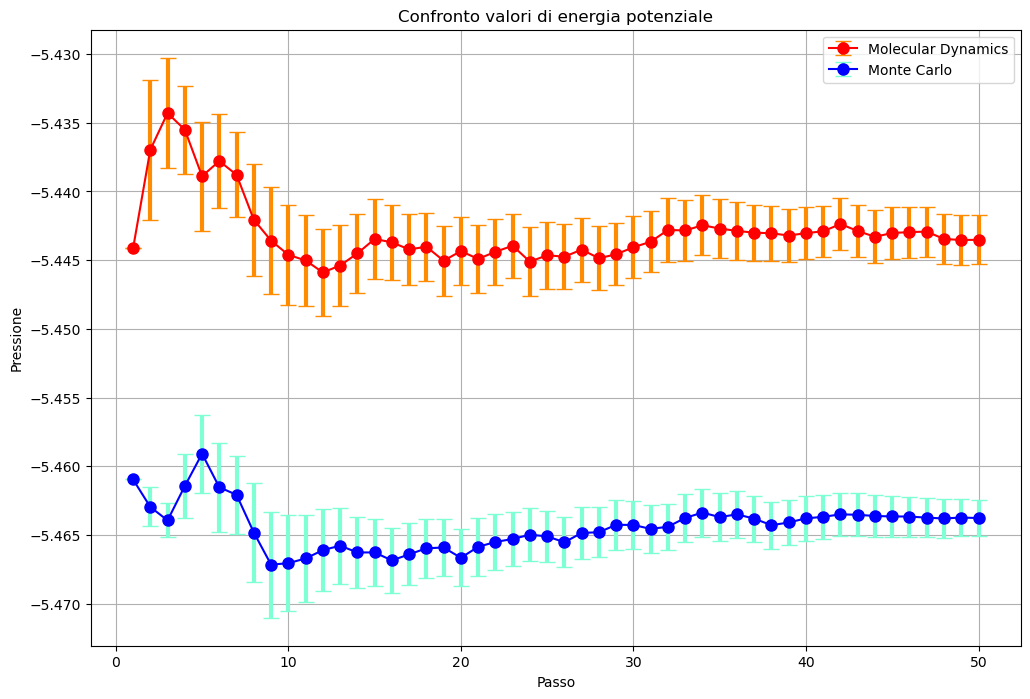

In [25]:
block, energy, error = np.loadtxt("Exercise_07.4/potential_energyMD07.4.dat", usecols = (0, 2, 3), unpack = True)
plt.figure(figsize=(12, 8))

plt.errorbar(block, energy, yerr = error, fmt='o-', color='red', 
             ecolor='darkorange', elinewidth=3, capsize=6, markersize=8, label='Molecular Dynamics')

block, energy, error = np.loadtxt("Exercise_07.4/total_energyMC07.4.dat", usecols = (0, 2, 3), unpack = True)


plt.errorbar(block, energy, yerr = error, fmt='o-', color='blue', 
             ecolor='aquamarine', elinewidth=3, capsize=6, markersize=8, label='Monte Carlo')
plt.grid(True)
plt.title("Confronto valori di energia potenziale")
plt.xlabel("Passo")
plt.ylabel("Pressione")
plt.legend()
plt.plot()

Anche in questo caso, le differenze tra i due valori sono ora sensibilmente più vicini, anche se ancora non compatibili.